<a href="https://colab.research.google.com/github/samrudhi-shirode/Machine-Learning/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  K-means Clustering

## Build a model that creates customer groups who are frequently visiting the mall on basis of Age, Income and Spending

In [2]:
path = r"https://raw.githubusercontent.com/samrudhi-shirode/Datasets/refs/heads/main/Mall_Customers.csv"
import pandas as pd
df = pd.read_csv(path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Perform basic data quality checks

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
## Duplicated rows
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
# Missing values
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# Separate X features.Consider the features for which you want clusters to be formed.

You can perform EDA to decide which features to consider for cluster creation

In [10]:
X = df.drop(columns=['Gender','CustomerID'])
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [12]:
X.columns = ['Age','Income','Spending']
X.columns

Index(['Age', 'Income', 'Spending'], dtype='object')

## Data Cleaning and Preprocessing

In [13]:
X.dtypes

,0
Age,int64
Income,int64
Spending,int64


In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
).set_output(transform='pandas')

X_pre = num_pipe.fit_transform(X)
X_pre.head()

,Age,Income,Spending
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


# Model Building

In [16]:
pip install yellowbrick

In [17]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import kelbow_visualizer

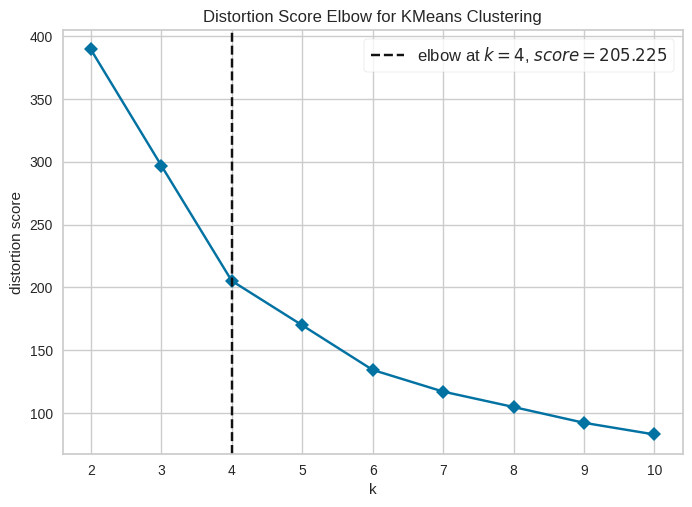

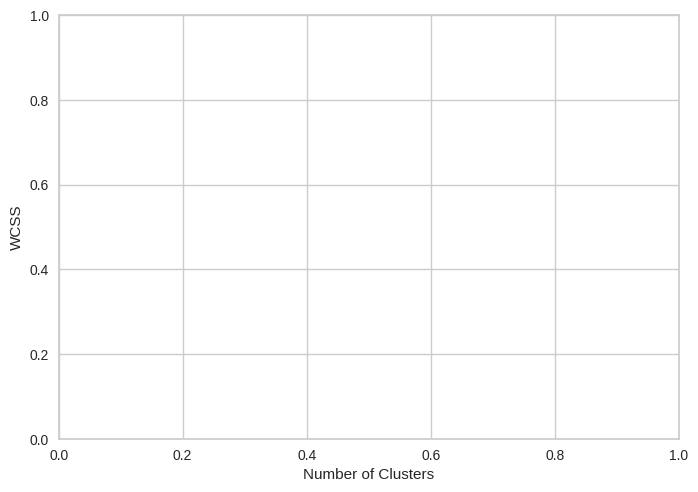

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
import matplotlib.pyplot as plt

base_model = KMeans()
visualizer = kelbow_visualizer(base_model,X_pre,k=(2,11),timings=False)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
visualizer.show()

In [21]:
# Build the model with K=6
final_model = KMeans(n_clusters=6) # k=n_clusters
clusters = final_model.fit_predict(X_pre) # cluster creation: 6 clusters , cluster information for each datapoint
clusters

array([3, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 1, 3, 0, 3,
       0, 3, 1, 5, 5, 5, 1, 5, 5, 1, 1, 1, 1, 1, 5, 1, 1, 5, 1, 1, 1, 5,
       1, 1, 5, 5, 1, 1, 1, 1, 1, 5, 1, 5, 5, 1, 1, 5, 1, 1, 5, 1, 1, 5,
       5, 1, 1, 5, 1, 5, 5, 5, 1, 5, 1, 5, 5, 1, 1, 5, 1, 5, 1, 1, 1, 1,
       1, 5, 5, 5, 5, 5, 1, 1, 1, 1, 5, 5, 5, 2, 5, 2, 4, 2, 4, 2, 4, 2,
       5, 2, 5, 2, 4, 2, 5, 2, 4, 2, 5, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2], dtype=int32)

In [22]:
final_model.cluster_centers_

array([[ 0.47895722, -1.30822992, -1.19644353],
       [ 1.25472096, -0.24021294, -0.04399777],
       [-0.44191719,  0.99158305,  1.23950275],
       [-0.97602698, -1.32549704,  1.0371827 ],
       [ 0.27091925,  1.10223769, -1.2755309 ],
       [-0.88539853, -0.09869244, -0.13617409]])

In [23]:
X.head()

,Age,Income,Spending
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [24]:
X['Customer_Groups'] = clusters
X.head()

,Age,Income,Spending,Customer_Groups
0,19,15,39,3
1,21,15,81,3
2,20,16,6,0
3,23,16,77,3
4,31,17,40,0


In [25]:
fil1 = X['Customer_Groups']==0
X[fil1]

,Age,Income,Spending,Customer_Groups
2,20,16,6,0
4,31,17,40,0
6,35,18,6,0
8,64,19,3,0
10,67,19,14,0
12,58,20,15,0
14,37,20,13,0
16,35,21,35,0
18,52,23,29,0
20,35,24,35,0


In [26]:
for i in range(6):
  print(f'Cluster {i}')
  display(X[X['Customer_Groups']==i])
  print('=======================')

Cluster 0


,Age,Income,Spending,Customer_Groups
2,20,16,6,0
4,31,17,40,0
6,35,18,6,0
8,64,19,3,0
10,67,19,14,0
12,58,20,15,0
14,37,20,13,0
16,35,21,35,0
18,52,23,29,0
20,35,24,35,0


Cluster 1


,Age,Income,Spending,Customer_Groups
40,65,38,35,1
46,50,40,55,1
50,49,42,52,1
53,59,43,60,1
54,50,43,45,1
55,47,43,41,1
56,51,44,50,1
57,69,44,46,1
59,53,46,46,1
60,70,46,56,1


Cluster 2


...

,Age,Income,Spending,Customer_Groups
0,19,15,39,3
1,21,15,81,3
3,23,16,77,3
5,22,17,76,3
7,23,18,94,3
9,30,19,72,3
11,35,19,99,3
13,24,20,77,3
15,22,20,79,3
17,20,21,66,3


Cluster 4


,Age,Income,Spending,Customer_Groups
126,43,71,35,4
128,59,71,11,4
130,47,71,9,4
136,44,73,7,4
140,57,75,5,4
144,25,77,12,4
146,48,77,36,4
148,34,78,22,4
150,43,78,17,4
152,44,78,20,4


Cluster 5


,Age,Income,Spending,Customer_Groups
47,27,40,47,5
48,29,40,42,5
49,31,40,42,5
51,33,42,60,5
52,31,43,54,5
58,27,46,51,5
61,19,46,55,5
65,18,48,59,5
68,19,48,59,5
69,32,48,47,5


## Clusters-Visualization

In [27]:
X.columns

Index(['Age', 'Income', 'Spending', 'Customer_Groups'], dtype='object')

In [29]:
import plotly.express as ex
fig = ex.scatter_3d(X,x='Age',y='Income',z='Spending',color='Customer_Groups')
fig.show()

# Save the X file

In [31]:
X.to_csv("Mall_Customers_Groups.csv",index=False)

# Assignment:
    1.Perform the above steps considering features Gender and Spending
    2.Perform the above steps considering all the features except customer ID.